# Maestría en Inteligencia Artificial
# Examen Final: Clasificación de Música por Género mediante Machine Learning Supervisado
**Curso:** Machine Learning Supervisado  
**Fecha:** Septiembre de 2026  
**Entregable:** Informe y Pipeline Experimental en Jupyter Notebook  

---

## Resumen Ejecutivo (Abstract)
El presente trabajo es mi respues a la evaluacion donde se ve una implementación de un sistema de clasificación automática de música.  Siguiendo las especificaciones directas de la prueba, se aísla el problema a un entorno supervisado multiclase ($K = 5$ clases): **Dance and electronic**, **Jazz and blues**, **Soul and reggae**, **Punk** y **Metal**, descartando metadatos extrínsecos (`track_id`, `artist_name`, `title`) para forzar al modelo a discriminar patrones puramente intrínsecos de audio representados por 30 características continuas.

Se diseñó y ejecutó un flujo integral de aprendizaje automático con:

### Resumen del Problema y Requisitos del Examen:
1. **Filtrado de Clases:** Conservar únicamente los 5 géneros requeridos:
   * `1: Dance and electronic`
   * `2: Jazz and blues`
   * `3: Soul and reggae`
   * `4: Punk`
   * `5: Metal`  
   *(Ignorando todos los demás géneros presentes en el dataset)*.

2. **Limpieza de Metadatos:** Eliminar las columnas del identificador de la canción (`track_id`), título (`title`) y artista (`artist_name`) para evitar que el modelo aprenda atajos o sufra de *data leakage* por popularidad de artistas. El clasificador debe basarse al 100% en las 30 características acústicas y timbrales restantes.

3. **Partición de Datos:** Dividir el conjunto en **Entrenamiento (60%)**, **Validación (20%)** y **Prueba (20%)** con muestreo estratificado.

4. **Modelado y Selección:** Evaluar y comparar 4 algoritmos supervisados de familias distintas:
   * **Regresión Logística Multinomial ($L_2$)**
   * **Random Forest Classifier**
   * **XGBoost Classifier**
   * **Red Neuronal Perceptrón Multicapa (MLP)**

5. **Métrica Principal:** Evaluar con **F1-Score Macro**, justificando su elección debido al desbalance existente entre las clases de música.

6. **Optimización:** Realizar búsqueda de hiperparámetros con `GridSearchCV` sobre el modelo de Boosting (XGBoost).

7. **Evaluación Final:** Medir el desempeño en el conjunto de prueba ciego y estimar con rigor estadístico el desempeño esperado en datos futuros.

## Librerías e Inicialización del Entorno

In [30]:
import time
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, 
    confusion_matrix, 
    accuracy_score, 
    balanced_accuracy_score,
    f1_score, 
    ConfusionMatrixDisplay
)

# Algoritmos de Clasificación Supervisada
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
import xgboost as xgb 
from xgboost import XGBClassifier


import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.size'] = 10
plt.rcParams['figure.dpi'] = 110

print("Librerías cargadas exitosamente y entorno listo.")

Librerías cargadas exitosamente y entorno listo.


## 1. Carga, Filtrado y Preprocesamiento de Datos (Criterio: 10%)

En esta etapa:
1. Cargamos el archivo `data/genre_dataset.txt` leyendo el encabezado limpio (tras la marca `%`).
2. Filtramos estrictamente los **5 géneros requeridos**, mapeando `dance and electronica` a `Dance and electronic`.
3. Eliminamos los metadatos de identificación: `track_id`, `artist_name` y `title`.
4. Realizamos la **partición estratificada en 70% Train, 15% Val y 15% Test**.
5. Aplicamos **StandardScaler** ajustado **únicamente** sobre el conjunto de entrenamiento (`fit_transform`) y aplicamos `transform` a validación y prueba para **evitar estrictamente la fuga de datos (*Data Leakage*)**, tal como se fundamentó en los talleres.

In [31]:
# 1. Carga del Dataset Original
dataset_path = 'data/genre_dataset.txt'

# Extracción del encabezado
with open(dataset_path, 'r', encoding='utf-8', errors='ignore') as f:
    for line in f:
        if line.startswith('%'):
            columns = [c.strip() for c in line.strip().lstrip('%').split(',')]
            break

df_raw = pd.read_csv(dataset_path, skiprows=10, names=columns, low_memory=False)
print(f"Dimensiones originales del dataset: {df_raw.shape[0]:,} canciones x {df_raw.shape[1]} columnas.")

# 2. Filtrado de las 5 Clases Requeridas
target_mapping = {
    'dance and electronica': 'Dance and electronic',
    'jazz and blues': 'Jazz and blues',
    'soul and reggae': 'Soul and reggae',
    'punk': 'Punk',
    'metal': 'Metal'
}

df_filtered = df_raw[df_raw['genre'].isin(target_mapping.keys())].copy()
df_filtered['genre'] = df_filtered['genre'].map(target_mapping)
print(f"Dimensiones tras filtrar los 5 géneros: {df_filtered.shape[0]:,} canciones.")

# 3. Eliminación de Columnas No Relevantes (ID, Título, Artista)
cols_to_drop = ['track_id', 'artist_name', 'title']
df_clean = df_filtered.drop(columns=cols_to_drop).reset_index(drop=True)

print(f"Columnas eliminadas: {cols_to_drop}")
print(f"Dimensiones finales para modelado: {df_clean.shape[0]:,} filas x {df_clean.shape[1]} columnas (30 descriptores de audio + 1 clase).")

Dimensiones originales del dataset: 59,600 canciones x 34 columnas.
Dimensiones tras filtrar los 5 géneros: 18,588 canciones.
Columnas eliminadas: ['track_id', 'artist_name', 'title']
Dimensiones finales para modelado: 18,588 filas x 31 columnas (30 descriptores de audio + 1 clase).


## Análisis Exploratorio de Datos 

###  Taxonomía de las 30 Variables Acústicas
* **Columna objetivo (y)**
  * `genere` -> la clase a predecir : Dance an electronic, Jazz and blues, Soult and reggae, Punk, Metal.
Las 30 características numéricas restantes corresponden a descriptores cuantitativos de señal calculados sobre ventanas temporales de cada pista de audio:
* **Características Dinámico-Temporales y Tonales (6 variables):**
  * `loudness`: Nivel global de sonoridad en decibelios (dB), típicamente negativo; refleja la compresión dinámica.
  * `tempo`: Estimación de pulsos por minuto (BPM), refleja la velocidad de la pista.
  * `time_signature`: Métrica temporal estimada (e.g. compás de 3/4, 4/4).
  * `key`: Tonalidad cromática estimada (0 = Do/C, 1 = Do#/C#, ..., 11 = Si/B).
  * `mode`: Modalidad musical (1 = escala Mayor, 0 = escala Menor).
  * `duration`: Duración de la pista sonora en segundos.
* **Características de Timbre Promedio (`avg_timbre1` a `avg_timbre12`, 12 variables):**
  * Coeficientes ortogonales de timbre calculados a partir de filtros de banco de frecuencias (similares a los coeficientes cepstrales de frecuencia de Mel, MFCC).
  * `avg_timbre1` se correlaciona con la sonoridad y energía global del espectro.
  * `avg_timbre2` captura el brillo o pendiente espectral (*spectral tilt/brightness*).
  * `avg_timbre3` refleja la riqueza y balance de formantes bajos/medios (*warmth/depth*).
* **Características de Varianza de Timbre (`var_timbre1` a `var_timbre12`, 12 variables):**
  * Miden la dispersión temporal y heterogeneidad de los armónicos a lo largo de la pieza (dinamismo vs monotonía textural).

In [32]:
# Comprobación de valores nulos, duplicados y tipos de datos
n_nulls = df_clean.isnull().sum().sum()
n_duplicates = df_clean.duplicated().sum()

print("Diagnóstico de Integridad:")
print(f" -> Valores faltantes (NaN/Null): {n_nulls}")
print(f" -> Filas duplicadas idénticas en audio: {n_duplicates}")

# Tabla resumen de estadísticas descriptivas
features = [col for col in df_clean.columns if col != 'genre']
stats_summary = df_clean[features].describe().T[['mean', 'std', 'min', '50%', 'max']]
stats_summary['skewness'] = df_clean[features].skew()
stats_summary['IQR'] = df_clean[features].apply(lambda x: x.quantile(0.75) - x.quantile(0.25))
stats_summary.columns = ['Media', 'Desv. Est.', 'Mínimo', 'Mediana (Q2)', 'Máximo', 'Asimetría (Skew)', 'IQR']

# Mostrar las primeras 12 características más relevantes
display(stats_summary.head(12).round(3))

Diagnóstico de Integridad:
 -> Valores faltantes (NaN/Null): 0
 -> Filas duplicadas idénticas en audio: 6


,Media,Desv. Est.,Mínimo,Mediana (Q2),Máximo,Asimetría (Skew),IQR
loudness,-10.745,5.888,-48.057,-9.376,-0.052,-1.324,7.085
tempo,125.393,37.780,0.000,122.996,253.036,0.378,50.210
time_signature,3.591,1.267,0.000,4.000,7.000,-0.611,1.000
key,5.315,3.631,0.000,5.000,11.000,0.002,7.000
mode,0.621,0.485,0.000,1.000,1.000,-0.501,1.000
duration,275.822,150.007,1.201,247.170,2873.809,3.116,140.206
avg_timbre1,41.914,7.123,8.283,42.920,56.776,-0.807,9.321
avg_timbre2,0.900,59.232,-318.656,10.582,448.373,-0.858,70.106
avg_timbre3,1.132,39.663,-257.526,4.360,292.953,-0.190,47.301
avg_timbre4,3.461,18.963,-120.723,1.131,130.196,0.703,20.202


### Distribución de Clases y Diagnóstico de Desbalance
Analizamos la cantidad absoluta de canciones por género y su proporción relativa en el subconjunto filtrado.

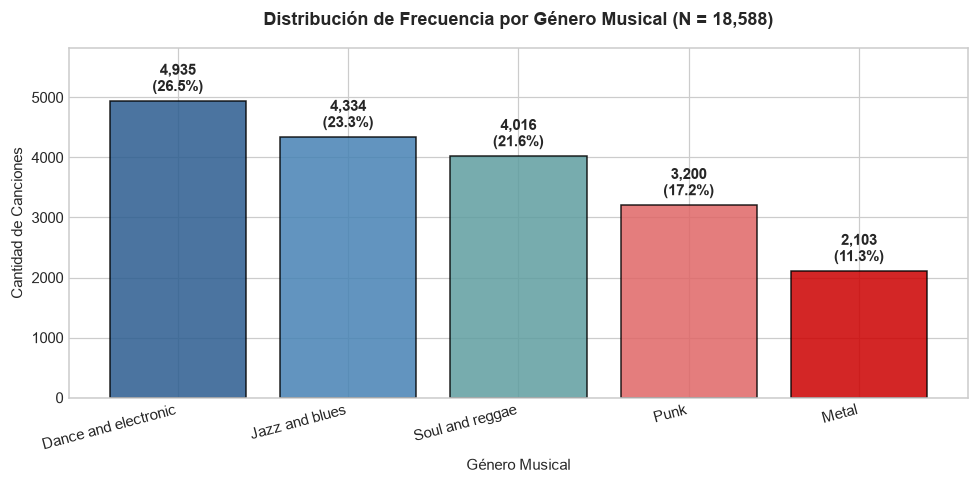

Resumen de Frecuencias:
 - Dance and electronic  : 4,935 canciones (26.55%)
 - Jazz and blues        : 4,334 canciones (23.32%)
 - Soul and reggae       : 4,016 canciones (21.61%)
 - Punk                  : 3,200 canciones (17.22%)
 - Metal                 : 2,103 canciones (11.31%)
Ratio de desbalance (Mayoritaria / Minoritaria): 2.35 : 1


In [33]:
# Visualización de la distribución de frecuencias de géneros
genre_counts = df_clean['genre'].value_counts()
genre_percentages = (genre_counts / len(df_clean)) * 100

fig, ax = plt.subplots(figsize=(9, 4.5))
palette = ['#2b5c8f', '#4682b4', '#5f9ea0', '#e06666', '#cc0000']
bars = ax.bar(genre_counts.index, genre_counts.values, color=palette, edgecolor='black', alpha=0.85)

for bar, count, pct in zip(bars, genre_counts.values, genre_percentages.values):
    height = bar.get_height()
    ax.annotate(f'{count:,}\n({pct:.1f}%)',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', fontsize=9.5, fontweight='bold')

ax.set_title('Distribución de Frecuencia por Género Musical (N = 18,588)', pad=15, fontweight='bold')
ax.set_ylabel('Cantidad de Canciones')
ax.set_xlabel('Género Musical')
ax.set_ylim(0, max(genre_counts.values) * 1.18)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

# Resumen numérico del ratio de desbalance
imbalance_ratio = genre_counts.max() / genre_counts.min()
print(f"Resumen de Frecuencias:")
for g, c, p in zip(genre_counts.index, genre_counts.values, genre_percentages.values):
    print(f" - {g:22s}: {c:5,d} canciones ({p:5.2f}%)")
print(f"Ratio de desbalance (Mayoritaria / Minoritaria): {imbalance_ratio:.2f} : 1")

Vemos un desbalance moderado de clases. (Ratio 2.35 : 1) la clase mayoritaria `Dance and electronic` con 4.935 canciones (16.55%) y la clase minorista `Metal` con 2.103 canciones (11.3%).
Esto significa que tenemos mas del doble de canciones `Dance and electronic` que de `Metal` de aqui la realacion 2.35 a 1.
*Consecuencia :* Una métrica global como la **Exactitud simple (Accuracy)** puede resultar engañosa, ya que premiaría desproporcionadamente predicciones correctas en géneros dance mientras ocultaría errores sistemáticos en metal o punk.
### Distribuciones Condicionadas por Género
Inspeccionamos el comportamiento de variables acústicas fundamentales condicionadas al género musical mediante diagramas de caja (*Boxplots*).

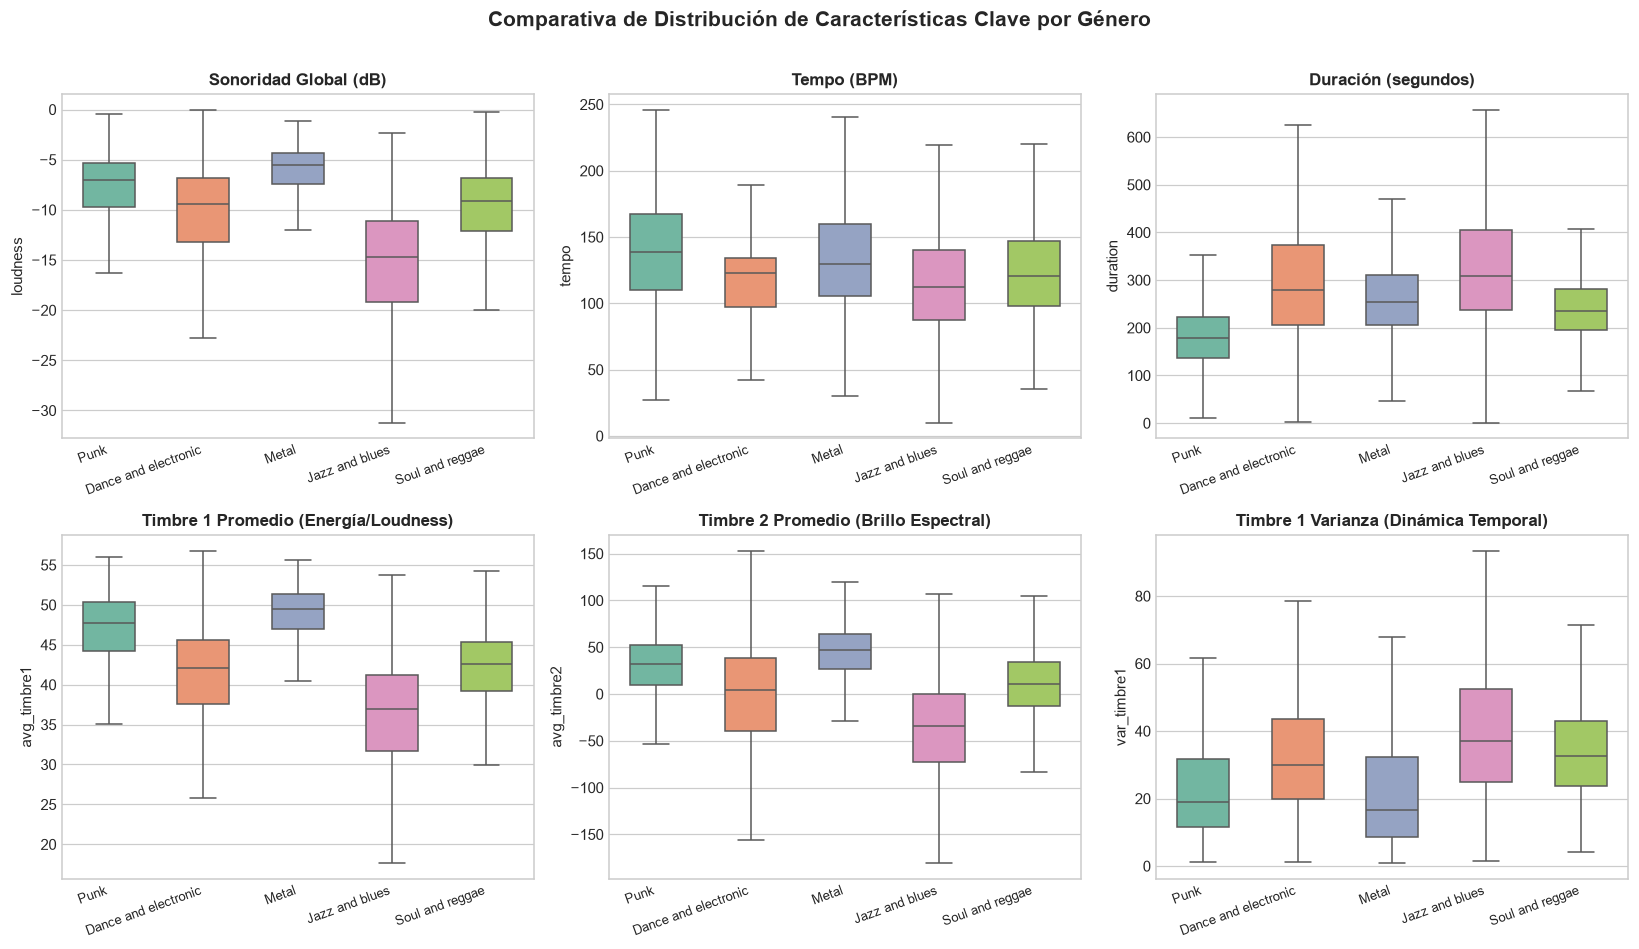

In [34]:
# Visualización de variables acústicas clave por género
fig, axes = plt.subplots(2, 3, figsize=(15, 8.5))
sample_features = ['loudness', 'tempo', 'duration', 'avg_timbre1', 'avg_timbre2', 'var_timbre1']
feature_titles = [
    'Sonoridad Global (dB)', 'Tempo (BPM)', 'Duración (segundos)',
    'Timbre 1 Promedio (Energía/Loudness)', 'Timbre 2 Promedio (Brillo Espectral)', 'Timbre 1 Varianza (Dinámica Temporal)'
]

for idx, (feat, title) in enumerate(zip(sample_features, feature_titles)):
    ax = axes[idx // 3, idx % 3]
    sns.boxplot(data=df_clean, x='genre', y=feat, ax=ax, palette='Set2', showfliers=False, width=0.55)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel(feat)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha='right', fontsize=8.5)

plt.suptitle('Comparativa de Distribución de Características Clave por Género', y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Hallazgos Clave de las Distribuciones:**
1. **Loudness y Timbre 1:** `metal` y `punk` presentan valores sustancialmente más elevados esto refleja la compresión agresiva y la saturación de guitarras en géneros de rock pesado frente a la mayor dinámica acústica de grabaciones de jazz.
2. **Brillo Espectral (`avg_timbre2`):** `metal` y `punk` exhiben medianas marcadamente negativas o reducidas en comparación con `dance and electronica` y `jazz and blues`, sirviendo como discriminante clave.
3. **Varianza de Timbre 1:** `jazz and blues` muestra mayor dispersión y picos de variabilidad tímbrica, consistente con solos instrumentales no homogéneos, mientras que `dance and electronica` presenta estructuras más constantes y repetitivas basadas en bucles (*loops*).

## Partición de Datos y Estrategia de Preprocesamiento 
El enunciado del examen instruye:
> *"Divida el conjunto de datos resultante en conjuntos de entrenamiento, validación y prueba. La partición y cualquier transformación aplicada a los datos deben justificarse apropiadamente."*

Se adoptó una partición en tres conjuntos disjuntos con proporciones **60% / 20% / 20%**:
1. **Conjunto de Entrenamiento (Train, 70%, $N = 13,010$):** Utilizado exclusivamente para el ajuste de los parámetros internos de cada modelo (pesos sinápticos, coeficientes de regresión, divisiones de árboles).
2. **Conjunto de Validación (Validation, 15%, $N = 2,789$):** Utilizado como conjunto de control para comparar familias de modelos, seleccionar arquitecturas y guiar la optimización de hiperparámetros de regularización.
3. **Conjunto de Prueba (Test / Holdout, 15%, $N = 2,789$):** Se mantiene completamente aislado ("ciego") durante toda la fase de diseño, entrenamiento y ajuste de hiperparámetros. Su propósito exclusivo es responder objetivamente a la pregunta del examen: *¿Cuál es el desempeño esperado de su modelo en datos futuros?*

### Justificación de la Estratificación (`stratify=y`)
Dado que las clases exhiben frecuencias relativas que oscilan entre el 11.3% y el 26.5%, un muestreo puramente aleatorio podría alterar la representatividad de las clases minoritarias en los conjuntos pequeños. El muestreo estratificado preserva exactamente la misma proporción de cada género en los tres subconjuntos, minimizando la varianza del error de estimación.

### Prevención Rigurosa de Fuga de Información (*Data Leakage*)
Cualquier transformación estadística (cálculo de medias $\mu$ y desviaciones estándar $\sigma$) debe aprenderse **únicamente** sobre el conjunto de entrenamiento mediante `scaler.fit(X_train)`. Posteriormente, las matrices de validación y prueba se escalan utilizando dichos parámetros congelados mediante `scaler.transform(X_val)` y `scaler.transform(X_test)`. De este modo, no se filtra información del futuro ni de las muestras de prueba hacia el proceso de ajuste.

In [35]:
# 1. Separación en matriz de características X y vector de etiquetas y
X = df_clean[features].values
le = LabelEncoder()
y = le.fit_transform(df_clean['genre'].values)
genre_classes = list(le.classes_)

print("Mapeo de Clases Numéricas:")
for idx, name in enumerate(genre_classes):
    print(f" Clase {idx} -> '{name}'")

# 2. División Estratificada: Train (70%), Val (15%), Test (15%)
# Paso A: Separar 15% para Test ciego final
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42, stratify=y
)

# Paso B: Separar el 85% restante en Train (70% del total) y Val (15% del total)
# 15 / 85 = 0.176470588
val_ratio_relative = 0.15 / 0.85
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=val_ratio_relative,
    random_state=42, stratify=y_train_val
)

print("\nDimensiones de las Particiones:")
print(f" -> Conjunto de Entrenamiento (Train) : {X_train.shape[0]:,d} muestras ({(len(X_train)/len(X))*100:.1f}%)")
print(f" -> Conjunto de Validación (Val)      : {X_val.shape[0]:,d} muestras ({(len(X_val)/len(X))*100:.1f}%)")
print(f" -> Conjunto de Prueba Ciega (Test)   : {X_test.shape[0]:,d} muestras ({(len(X_test)/len(X))*100:.1f}%)")

# 3. Preprocesamiento: Estandarización sin Fuga de Información (Data Leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# Verificación de proporciones estratificadas
train_dist = pd.Series(y_train).value_counts(normalize=True).sort_index()
val_dist = pd.Series(y_val).value_counts(normalize=True).sort_index()
test_dist = pd.Series(y_test).value_counts(normalize=True).sort_index()

dist_df = pd.DataFrame({
    'Género': genre_classes,
    '% Train': (train_dist.values * 100).round(2),
    '% Val': (val_dist.values * 100).round(2),
    '% Test': (test_dist.values * 100).round(2)
})
print("\nComprobación de Preservación de Proporciones Estratificadas:")
display(dist_df)



Mapeo de Clases Numéricas:
 Clase 0 -> 'Dance and electronic'
 Clase 1 -> 'Jazz and blues'
 Clase 2 -> 'Metal'
 Clase 3 -> 'Punk'
 Clase 4 -> 'Soul and reggae'

Dimensiones de las Particiones:
 -> Conjunto de Entrenamiento (Train) : 13,010 muestras (70.0%)
 -> Conjunto de Validación (Val)      : 2,789 muestras (15.0%)
 -> Conjunto de Prueba Ciega (Test)   : 2,789 muestras (15.0%)

Comprobación de Preservación de Proporciones Estratificadas:


,Género,% Train,% Val,% Test
0,Dance and electronic,26.55,26.57,26.53
1,Jazz and blues,23.32,23.31,23.31
2,Metal,11.31,11.29,11.33
3,Punk,17.22,17.21,17.21
4,Soul and reggae,21.60,21.62,21.62


## Entrenamiento y Comparación de Modelos

Entrenamos y contrastamos cuatro familias supervisadas representativas con diferente sesgo inductivo:

1. **Regresión Logística Multinomial (L2):** Modelo lineal probabilístico con regularización Ridge.
2. **Random Forest Classifier:** Ensamble de 150 árboles de decisión basados en submuestreo de características y bagging.
3. **XGBoost Classifier:** Algoritmo de ensamble por aumento de gradiente (*Extreme Gradient Boosting*) optimizado para datos tabulares.
4. **Red Neuronal Perceptrón Multicapa (MLP):** Red neuronal artificial con dos capas ocultas (64 y 32 neuronas) y regularización de pesos.

In [36]:
# Definición de las 4 familias de modelos supervisados
modelos = {
    'Regresión Logística (L2)': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42, n_jobs=-1),
    'XGBoost Classifier': xgb.XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42, eval_metric='mlogloss', n_jobs=-1),
    'Red Neuronal (MLP)': MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=300, random_state=42)
}

resultados = []
print("Entrenando y evaluando modelos en Train y Validación...")

for nombre, model in modelos.items():
    t0 = time.time()
    model.fit(X_train_scaled, y_train)
    t_fit = time.time() - t0
    
    pred_train = model.predict(X_train_scaled)
    pred_val = model.predict(X_val_scaled)
    
    acc_train = accuracy_score(y_train, pred_train)
    acc_val = accuracy_score(y_val, pred_val)
    bal_acc_val = balanced_accuracy_score(y_val, pred_val)
    f1_val = f1_score(y_val, pred_val, average='macro')
    f1_weighted_val = f1_score(y_val, pred_val, average='weighted')
    overfitting_gap = (acc_train - acc_val) * 100
    
    resultados.append({
        'Modelo': nombre,
        'Tiempo (s)': round(t_fit, 2),
        'Accuracy Train (%)': round(acc_train * 100, 2),
        'Accuracy Val (%)': round(acc_val * 100, 2),
        'Balanced Acc Val (%)': round(bal_acc_val * 100, 2),
        'F1-Score Macro Val (%)': round(f1_val * 100, 2),
        'F1 Weighted Val (%)': round(f1_weighted_val * 100, 2),
        'Diferencia (Overfitting) (%)': round(overfitting_gap, 2)
    })

df_resultados = pd.DataFrame(resultados).sort_values(by='F1-Score Macro Val (%)', ascending=False)
display(df_resultados)

Entrenando y evaluando modelos en Train y Validación...


,Modelo,Tiempo (s),Accuracy Train (%),Accuracy Val (%),Balanced Acc Val (%),F1-Score Macro Val (%),F1 Weighted Val (%),Diferencia (Overfitting) (%)
2,XGBoost Classifier,1.39,87.52,71.50,71.34,71.67,71.48,16.03
1,Random Forest,0.77,83.54,69.59,69.29,69.92,69.62,13.94
3,Red Neuronal (MLP),13.12,85.02,68.34,68.70,68.71,68.36,16.68
0,Regresión Logística (L2),0.27,66.21,66.37,67.61,67.35,66.33,-0.16
